In [2]:
#Present for Jieun
import numpy as np 
import pandas as pd
import mne
import os.path as op
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d # <----- Important one for smoothing

In [3]:
s = '029'
sub = f'vml_meg_{s}'
subject = f'vml_mri_{s}'
path = '/users/mgarson.stu/.anaconda/VML/'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')

In [4]:
#Read in Source Estimate and source space
stc = mne.read_source_estimate(op.join(meg_path, sub, f'DS_{s}_cond-left no-rotation-stc.h5')) #stc file
times = stc.times
fwd = mne.read_forward_solution(op.join(meg_path, sub, f'{s}-cerebellar-fw-solution-run.fif')) #forward solution
src = fwd['src'] # source space

Reading forward solution from c:\users\mgarson.stu\.anaconda\VML\MEG\vml_meg_029\029-cerebellar-fw-solution-run.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    Reading a source space...


C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_3432\2699179192.py:4: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML/MEG\vml_meg_029\029-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(meg_path, sub, f'{s}-cerebellar-fw-solution-run.fif')) #forward solution


    [done]
    6 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (21447 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


In [5]:
print(src)

<SourceSpaces: [<surface (lh), n_vertices=117148, n_used=10242>, <surface (rh), n_vertices=115309, n_used=10242>, <volume (Right-Cerebellum-Cortex), n_used=381>, <volume (Right-Cerebellum-White-Matter), n_used=110>, <volume (Left-Cerebellum-Cortex), n_used=378>, <volume (Left-Cerebellum-White-Matter), n_used=94>] head coords, subject 'vml_mri_029', ~317.0 MB>


Reading labels from parcellation...
   read 34 labels from c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_029\label\lh.aparc.annot
   read 34 labels from c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_029\label\rh.aparc.annot
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)


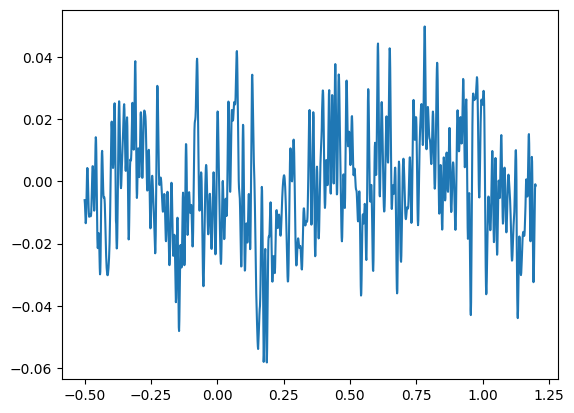

In [6]:
#Extract Label Timecourses(TCs)
wanted_surf_labels = ['superiorparietal-lh', 'superiorparietal-rh', 'inferiorparietal-lh', 'inferiorparietal-rh'] #Examples of labels from aparc parcellation
surf_labels = mne.read_labels_from_annot(subject=subject, parc='aparc', subjects_dir=mri_path)
surf_labels = [label for label in surf_labels if label.name in wanted_surf_labels] #Keep only the timecourses from the labels that we want 

superiorparietal_lh_tc = mne.extract_label_time_course(stc, labels=surf_labels[0], src=src, mode='mean')[0]
superiorparietal_rh_tc = mne.extract_label_time_course(stc, labels=surf_labels[1], src=src, mode='mean')[0] 
inferiorrparietal_lh_tc = mne.extract_label_time_course(stc, labels=surf_labels[2], src=src, mode='mean')[0] 
inferiorparietal_rh_tc = mne.extract_label_time_course(stc, labels=surf_labels[3], src=src, mode='mean')[0]  
####JIEUN PLS REMOVE THE [0] AT THE END OF THIS LINE ^^^^^ FOR THIS TO WORK. I AM USING MIXED SOURCE SPACE SO I GET FIVE TIMECOURSES, I THINK YOU WILL ONLY GET ONE ###

plt.plot(times, superiorparietal_lh_tc)
#At this point you should have a plot of the RAW timecourse from whatever brain region you want 

(0.0, 0.5)

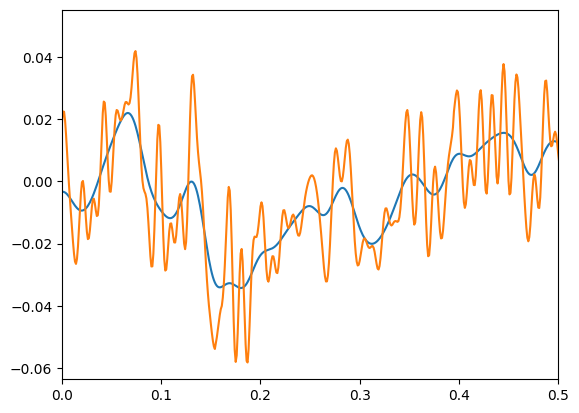

In [7]:
#Smoothing: 
'''Here my epochs are from -500ms to 1200ms. 
You can chose to baseline correct the data depeding 
on the research question and epoch lengths'''

sigma = 10 #Amount of smoothing parameter
#baseline = np.mean(superiorparietal_lh_tc[0:200])#Baseline Normalization from -500ms to -300ms. Add/Change this as needed
# for i in range(len(superiorparietal_lh_tc)):
#     superiorparietal_lh_tc[i] = superiorparietal_lh_tc[i] - baseline

sigma = 10 #Amount of smoothing parameter
smooth_tc = gaussian_filter1d(superiorparietal_lh_tc, sigma=sigma)
plt.plot(times, smooth_tc) #Visually inspect to set sigma for desired amount of smoothing 
plt.plot(times, superiorparietal_lh_tc)
plt.xlim(0,0.5)

Found 3 significant peaks


(0.0, 0.5)

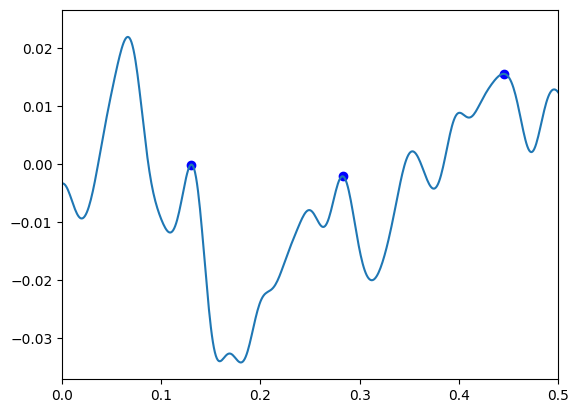

In [8]:
#Peak Extracting 

#Range in which to look for peaks. For my data, this is 100ms-500ms after onset of STIM. 
min = 600
maxi = 1000
psi = 4 #Adjust to control sensitivity of # of peaks. Higher = More Peaks

thresh = (np.max(smooth_tc[min:maxi]) - np.min(smooth_tc[min:maxi])) / psi
peaks, _ = mne.preprocessing.peak_finder(smooth_tc[min:maxi], thresh=thresh)
peaks = peaks + min

plt.plot(times, smooth_tc)
plt.scatter(times[peaks], smooth_tc[peaks], color='blue')
plt.xlim(0,0.5)

In [9]:
time_of_largest_peak = np.max(times[peaks])
time_of_first_peak = times[peaks[0]]
print(time_of_first_peak, 'time of the first peak', time_of_largest_peak, 'time of the largest peak')

0.13 time of the first peak 0.44500000000000006 time of the largest peak
